<div style="
    font-size: 16px;
    font-weight: bold;
    padding: 6px;
    border-radius: 5px;
    margin: 10px 0;
">
    Here we load and clean the historical data of loan transactions. This data was sourced from Kaggle therefore it is anonymised. 
</div>

<div style="
    font-size: 14px;
    font-weight: bold;
    font-color: #e0e0e0;
    padding: 6px;
    border-radius: 5px;
    margin: 10px 0;
">
    Dataset:
</div> <div style="
    font-size: 14px;
    padding: 6px;
    border-radius: 5px;
    margin: 10px 0;
">
    LendingClub Loan Data (CSV) https://www.kaggle.com/datasets/adarshsng/lending-club-loan-data-csv?select=loan.csv
</div>

API Token: KGAT_cdf2d2fa99f9d84e96b233acfaab95fb

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
use_cols = [
    "loan_status",
    "loan_amnt",
    "term",
    "int_rate",
    "installment",
    "annual_inc",
    "dti",
    "grade",
    "open_acc",
    "revol_util",
    "earliest_cr_line",
    "issue_d"
]
    

data = pd.read_csv(r"C:\Users\thany\Downloads\loan.csv\loan.csv", usecols=use_cols)

<div style="
    font-size: 14px;
    font-weight: bold;
    padding: 6px;
    border-radius: 5px;
    margin: 10px 0;
">
    A quick inspection of the data before we proceed.
</div>

In [3]:
data.head()

,loan_amnt,term,int_rate,installment,grade,annual_inc,issue_d,loan_status,dti,earliest_cr_line,open_acc,revol_util
0,2500,36 months,13.56,84.92,C,55000.0,Dec-2018,Current,18.24,Apr-2001,9.0,10.3
1,30000,60 months,18.94,777.23,D,90000.0,Dec-2018,Current,26.52,Jun-1987,13.0,24.2
2,5000,36 months,17.97,180.69,D,59280.0,Dec-2018,Current,10.51,Apr-2011,8.0,19.1
3,4000,36 months,18.94,146.51,D,92000.0,Dec-2018,Current,16.74,Feb-2006,10.0,78.1
4,30000,60 months,16.14,731.78,C,57250.0,Dec-2018,Current,26.35,Dec-2000,12.0,3.6


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260668 entries, 0 to 2260667
Data columns (total 12 columns):
 #   Column            Dtype  
---  ------            -----  
 0   loan_amnt         int64  
 1   term              object 
 2   int_rate          float64
 3   installment       float64
 4   grade             object 
 5   annual_inc        float64
 6   issue_d           object 
 7   loan_status       object 
 8   dti               float64
 9   earliest_cr_line  object 
 10  open_acc          float64
 11  revol_util        float64
dtypes: float64(6), int64(1), object(5)
memory usage: 207.0+ MB


In [5]:
print(data["loan_status"].value_counts())

print("Here we see the statuses of the loans of the clients.")

loan_status
Fully Paid                                             1041952
Current                                                 919695
Charged Off                                             261655
Late (31-120 days)                                       21897
In Grace Period                                           8952
Late (16-30 days)                                         3737
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     31
Name: count, dtype: int64
Here we see the statuses of the loans of the clients.


In [6]:
print(data["grade"].value_counts())

grade
B    663557
C    650053
A    433027
D    324424
E    135639
F     41800
G     12168
Name: count, dtype: int64


<div style="
    font-size: 14px;
    font-weight: bold;
    padding: 6px;
    border-radius: 5px;
    margin: 10px 0;
">
    The original dataset was very large and contained a lot of information that we do not need for this model so we have trimmed it down for better loading speed and cleaner reading. It initially had 145 columns, we have selected eleven of the ones we need. 5 of the 11 columns contains float entries, that is decimal point numbers. 2 of the columns have integer values and 4 of them are objects. We have also trimmed the dataset to just the first 1,000,000 entries to train and test our model with.
</div>

In [7]:
# We will create a new column Crediy History Years from the object column earliest_cr_line.

data["earliest_cr_line"] = pd.to_datetime(data["earliest_cr_line"], format="%b-%Y", errors="coerce")
data["issue_d"] = pd.to_datetime(data["issue_d"], format="%b-%Y", errors="coerce")

data["credit_history_years"] = (data['issue_d'] - data["earliest_cr_line"]).dt.days/365

data["credit_history_years"] = data["credit_history_years"].round(1)

In [8]:
# We first create a column of defaulted and paid off loans from clients
data = data[data["loan_status"].isin(["Fully Paid", "Charged Off"])].copy()
data.loc[:, "default"] = data["loan_status"].map({
    "Fully Paid": 0,
    "Charged Off": 1
})


In [9]:
data[["credit_history_years", "default"]].head()
data["credit_history_years"].describe()

count    1.303607e+06
mean     1.626357e+01
std      7.498408e+00
min      3.000000e+00
25%      1.130000e+01
50%      1.480000e+01
75%      2.000000e+01
max      8.330000e+01
Name: credit_history_years, dtype: float64

In [10]:
# The cell below produced a ValueError at first so we are making a minor change to fix that

data["term"] = (
    data["term"].astype(str).str.extract(r"(\d+)").astype(int))

<div style="
    font-size: 16px;
    font-weight: bold;
    padding: 6px;
    border-radius: 5px;
    margin: 10px 0;
">
    Now we will encode some features and also split the dataset into what we'll use to train and what we'll use to test the model. 
</div>

In [11]:
data = data.sample(n = len(data), random_state=42)

In [12]:
Y = data["default"].values
X = data.loc[:, ~data.columns.isin(["default", 'loan_status'])]

In [13]:
X.dtypes, Y.shape # Confirmation

(loan_amnt                        int64
 term                             int64
 int_rate                       float64
 installment                    float64
 grade                           object
 annual_inc                     float64
 issue_d                 datetime64[ns]
 dti                            float64
 earliest_cr_line        datetime64[ns]
 open_acc                       float64
 revol_util                     float64
 credit_history_years           float64
 dtype: object,
 (1303607,))

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size = 0.2, # We use a 80/20 split
    random_state = 42,
    stratify=Y
)

In [15]:
numerical_features = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['category', 'object']).columns.tolist()

<div style="
    font-size: 16px;
    font-weight: bold;
    padding: 6px;
    border-radius: 5px;
    margin: 10px 0;
">
    We begin building the Processing Pipeline.
</div>

In [16]:
# While later building the regression model we were met with a NaN value so in this cell we will implement code to handle that error

from sklearn.impute import SimpleImputer

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

<div style="
    font-size: 14px;
    font-weight: bold;
    padding: 6px;
    border-radius: 5px;
    margin: 10px 0;
">
    We'll construct the linear regression model
</div>

In [18]:

from sklearn.linear_model import LogisticRegression

log_pipeline = Pipeline(
    steps = [
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter = 1000, class_weight='balanced', random_state=42))
         ]
)


In [19]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

log_param_grid = {
    "classifier__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "classifier__penalty": ["l1", "l2"],
    "classifier__solver": ["liblinear"],   # liblinear supports both l1 and l2
    "classifier__class_weight": [None, "balanced"]
}

In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [21]:
log_grid_search = GridSearchCV(estimator=log_pipeline,
                               param_grid=log_param_grid,
                               scoring='average_precision',
                               cv=cv,
                               n_jobs=2,
                               verbose=2)
log_grid_search.fit(X_train, Y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'classifier__C': [0.001, 0.01, ...], 'classifier__class_weight': [None, 'balanced'], 'classifier__penalty': ['l1', 'l2'], 'classifier__solver': ['liblinear']}"
,scoring,'average_precision'
,n_jobs,2
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [22]:
print("\nBest params:", log_grid_search.best_params_)
print("Best CV score:", log_grid_search.best_score_)
print("Best cross-validation score: {:.2f}".format(log_grid_search.best_score_))


Best params: {'classifier__C': 100, 'classifier__class_weight': None, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
Best CV score: 0.357119625247306
Best cross-validation score: 0.36


In [23]:
test_score = log_grid_search.score(X_test, Y_test)  
print("Test set score: {:.2f}".format(test_score))

Test set score: 0.36


<div style="
    font-size: 14px;
    font-weight: bold;
    padding: 6px;
    border-radius: 5px;
    margin: 10px 0;
">
    Now that we have our pipeline let's evaluate the model.
</div>

In [24]:
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score, recall_score, classification_report

In [25]:
best_log_model = log_grid_search.best_estimator_
Y_pred_check = best_log_model.predict(X_test)
Y_proba_check = best_log_model.predict_proba(X_test)[:, 1]

In [26]:
Y_pred = log_grid_search.predict(X_test)

In [27]:
Y_proba = Y_proba_check

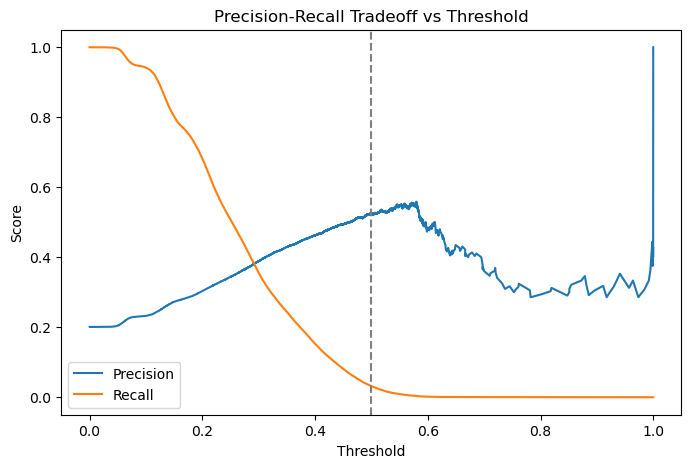

In [28]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(Y_test, Y_proba)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall Tradeoff vs Threshold")
plt.legend()
plt.axvline(x=0.5, color="gray", linestyle="--", label="Default threshold (0.5)")
plt.show()

Y_pred = log_model.predict(X_test)
Y_proba = log_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(Y_test, Y_pred))
print("ROC-AUC:", roc_auc_score(Y_test, Y_proba))

In [29]:
import numpy as np

target_recall = 0.65

# thresholds array is one shorter than precision/recall arrays
valid_idx = np.where(recall[:-1] >= target_recall)[0]

if len(valid_idx) > 0:
    # among thresholds hitting the target recall, pick the one with best precision
    best_idx = valid_idx[np.argmax(precision[:-1][valid_idx])]
    best_threshold = thresholds[best_idx]
    print(f"Chosen threshold: {best_threshold:.3f}")
    print(f"Precision at this threshold: {precision[best_idx]:.3f}")
    print(f"Recall at this threshold: {recall[best_idx]:.3f}")
else:
    print("No threshold achieves the target recall.")

Chosen threshold: 0.208
Precision at this threshold: 0.311
Recall at this threshold: 0.650


              precision    recall  f1-score   support

           0       0.88      0.64      0.74    208391
           1       0.31      0.65      0.42     52331

    accuracy                           0.64    260722
   macro avg       0.59      0.64      0.58    260722
weighted avg       0.76      0.64      0.68    260722



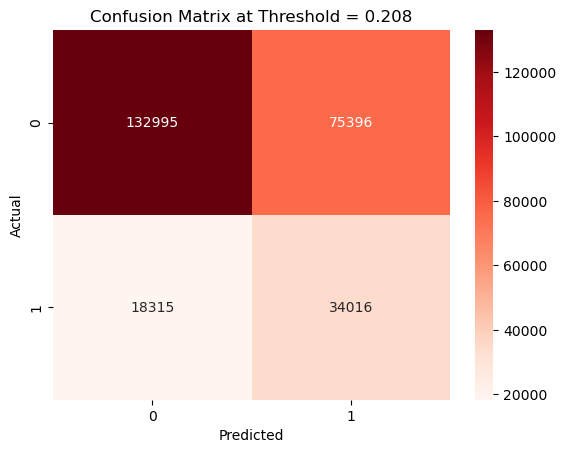

In [30]:
Y_pred_tuned = (Y_proba >= best_threshold).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(Y_test, Y_pred_tuned))

cm_tuned = confusion_matrix(Y_test, Y_pred_tuned)
sns.heatmap(cm_tuned, annot=True, fmt="d", cmap="Reds")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix at Threshold = {best_threshold:.3f}")
plt.show()

In [31]:
for target_recall in [0.5, 0.65, 0.75, 0.85]:
    valid_idx = np.where(recall[:-1] >= target_recall)[0]
    if len(valid_idx) > 0:
        best_idx = valid_idx[np.argmax(precision[:-1][valid_idx])]
        print(f"Recall={target_recall}: threshold={thresholds[best_idx]:.3f}, "
              f"precision={precision[best_idx]:.3f}")

Recall=0.5: threshold=0.253, precision=0.346
Recall=0.65: threshold=0.208, precision=0.311
Recall=0.75: threshold=0.177, precision=0.286
Recall=0.85: threshold=0.136, precision=0.260


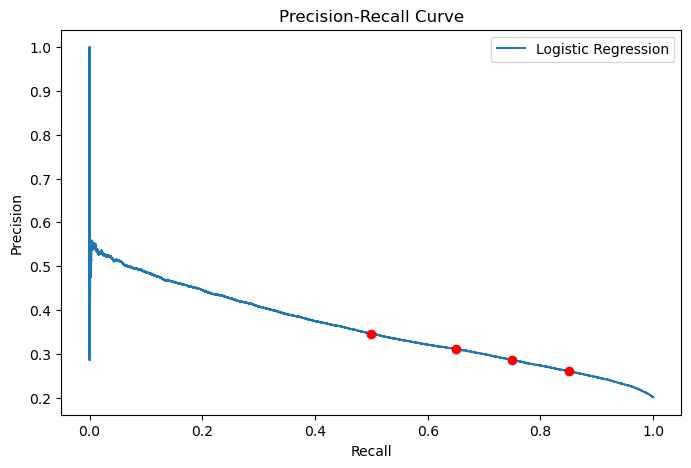

In [32]:
plt.figure(figsize=(8, 5))
plt.plot(recall, precision, label="Logistic Regression")
plt.scatter([0.5, 0.65, 0.75, 0.85], [0.346, 0.311, 0.286, 0.260], color="red", zorder=5)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

In [33]:
import joblib
model_metadata = {
    "model": best_log_model,
    "threshold": 0.208,
    "target_recall": 0.65
}
joblib.dump(model_metadata, "default_pred_log_with_threshold.pkl")

['default_pred_log_with_threshold.pkl']